In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import auc as sk_auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import joblib

import warnings
warnings.filterwarnings('ignore')

In [3]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
submission_df = pd.read_csv('sample_submission.csv')

In [4]:
target = 'diagnosed_diabetes'

In [5]:
X_train = train_df.drop(columns=[target, 'id'])
y_train = train_df[target]
X_test = test_df.drop(columns=['id'])

In [6]:
cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(exclude='object').columns

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [8]:
rf_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=400,
        max_depth=18,
        min_samples_leaf=30,
        min_samples_split=10,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_train)
rf_proba = rf_model.predict_proba(X_train)[:, 1]

print("\n=== Random Forest Evaluation ===")
print("Accuracy:", accuracy_score(y_train, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_train, rf_pred))
print("\nClassification Report:\n", classification_report(y_train, rf_pred))


=== Random Forest Evaluation ===
Accuracy: 0.6842785714285714
Confusion Matrix:
 [[192930  70763]
 [150242 286065]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.56      0.73      0.64    263693
         1.0       0.80      0.66      0.72    436307

    accuracy                           0.68    700000
   macro avg       0.68      0.69      0.68    700000
weighted avg       0.71      0.68      0.69    700000



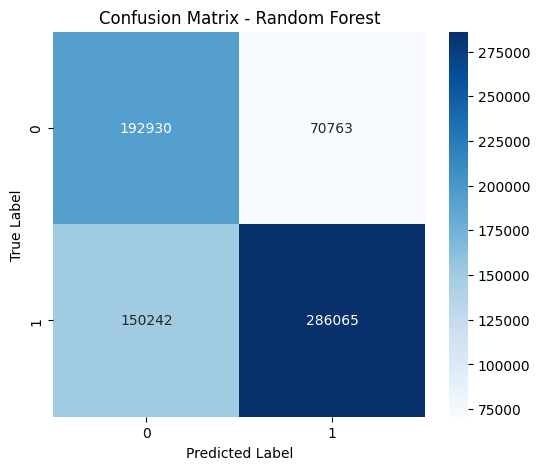

In [9]:
cm = confusion_matrix(y_train, rf_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.savefig("rf_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

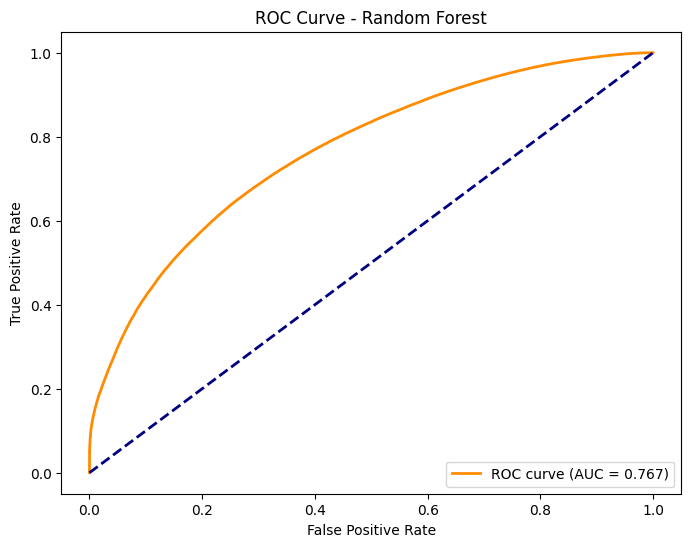

In [10]:
fpr, tpr, _ = roc_curve(y_train, rf_proba)
roc_auc = sk_auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')

plt.savefig("rf_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
joblib.dump(rf_model, "rf_model.pkl")
print("Random Forest saved as rf_model.pkl")

Random Forest saved as rf_model.pkl


In [12]:
submission_df['diagnosed_diabetes'] = rf_model.predict_proba(X_test)[:, 1]
submission_df.to_csv('submission_random_forest.csv', index=False)

In [13]:
neg = y_train.value_counts()[0]
pos = y_train.value_counts()[1]
scale_pos_weight = neg / pos

xgb_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', XGBClassifier(
        n_estimators=800,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=scale_pos_weight
    ))
])

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_train)
xgb_proba = xgb_model.predict_proba(X_train)[:, 1]

print("\n=== XGBoost Evaluation ===")
print("Accuracy:", accuracy_score(y_train, xgb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_train, xgb_pred))
print("\nClassification Report:\n", classification_report(y_train, xgb_pred))


=== XGBoost Evaluation ===
Accuracy: 0.7074957142857143
Confusion Matrix:
 [[197396  66297]
 [138456 297851]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.59      0.75      0.66    263693
         1.0       0.82      0.68      0.74    436307

    accuracy                           0.71    700000
   macro avg       0.70      0.72      0.70    700000
weighted avg       0.73      0.71      0.71    700000



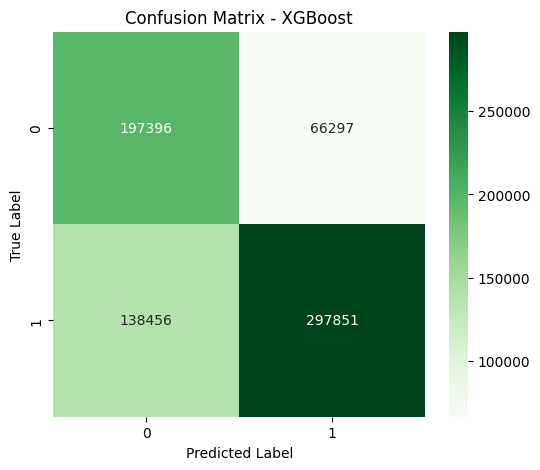

In [14]:
cm = confusion_matrix(y_train, xgb_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.savefig("XGBoost_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

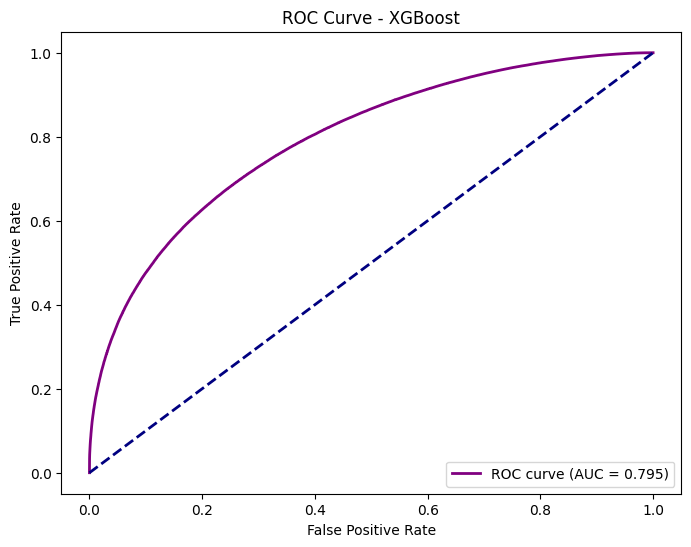

In [15]:
fpr, tpr, _ = roc_curve(y_train, xgb_proba)
roc_auc = sk_auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')

plt.savefig("XGBoost_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
joblib.dump(xgb_model, "xgb_model.pkl")
print("XGBoost saved as xgb_model.pkl")

XGBoost saved as xgb_model.pkl


In [17]:
submission_df['diagnosed_diabetes'] = xgb_model.predict_proba(X_test)[:, 1]
submission_df.to_csv('submission_xgboost.csv', index=False)

In [18]:
X_train_nn = preprocessor.fit_transform(X_train)
X_test_nn = preprocessor.transform(X_test)

ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['AUC']
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

ann_model.fit(
    X_train_nn, y_train,
    epochs=100,
    batch_size=1024,
    verbose=1,
    class_weight=class_weights 
)

loss, train_auc = ann_model.evaluate(X_train_nn, y_train, verbose=1)
print(f"Training Loss: {loss:.4f}")
print(f"Training AUC: {train_auc:.4f}")

ann_proba = ann_model.predict(X_train_nn).ravel()
ann_pred = (ann_proba > 0.5).astype(int)

print("\n=== ANN Evaluation ===")
print("Accuracy:", accuracy_score(y_train, ann_pred))
print("Confusion Matrix:\n", confusion_matrix(y_train, ann_pred))
print("\nClassification Report:\n", classification_report(y_train, ann_pred))

Epoch 1/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - AUC: 0.6827 - loss: 0.6372
Epoch 2/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.6923 - loss: 0.6312
Epoch 3/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.6936 - loss: 0.6302
Epoch 4/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.6942 - loss: 0.6300
Epoch 5/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.6947 - loss: 0.6296
Epoch 6/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.6952 - loss: 0.6292
Epoch 7/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.6954 - loss: 0.6291
Epoch 8/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - AUC: 0.6957 - loss: 0.6288
Epoch 9/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.6958 - loss: 0.6288
Epoch 10/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - AUC: 0.6961 - loss: 0.6285
Epoch 11/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.6964 - loss: 0.6285
Epoch 12/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.6964 - loss: 0.6283
Epoch 13/100


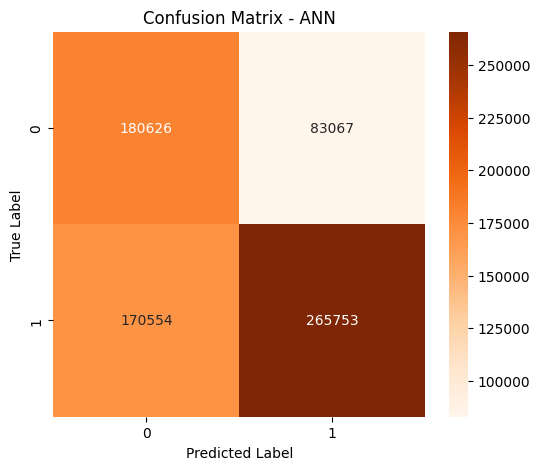

In [19]:
cm = confusion_matrix(y_train, ann_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - ANN')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.savefig("ann_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

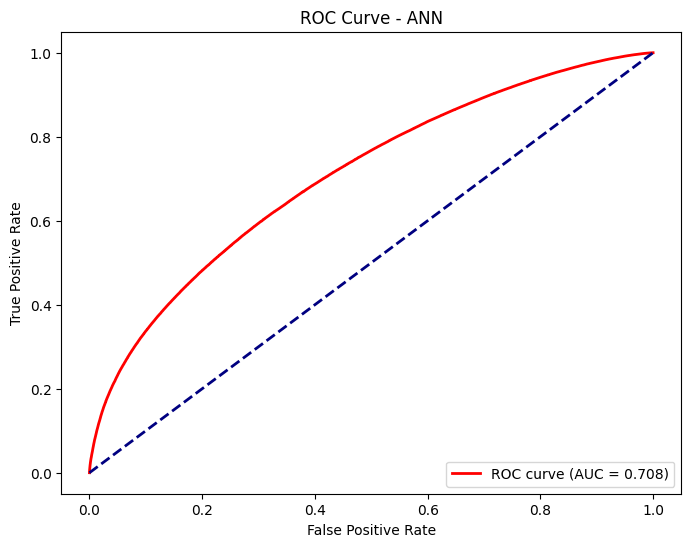

In [20]:
fpr, tpr, _ = roc_curve(y_train, ann_proba)
roc_auc = sk_auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ANN')
plt.legend(loc='lower right')

plt.savefig("ann_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

In [21]:
joblib.dump(preprocessor, "preprocessor.pkl")
print("Preprocessor saved as preprocessor.pkl")

Preprocessor saved as preprocessor.pkl


In [22]:
ann_model.save("ann_model.h5")
print("ANN model saved as ann_model.h5")

ANN model saved as ann_model.h5


In [23]:
submission_df['diagnosed_diabetes'] = ann_model.predict(X_test_nn).ravel()
submission_df.to_csv('submission_ann.csv', index=False)

9375/9375 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


In [24]:
def evaluate_model(model, X_data, y_data, model_name, is_nn=False):
    if is_nn:
        y_pred_proba = model.predict(X_data).ravel()
        y_pred = (y_pred_proba > 0.5).astype(int)
    else:
        y_pred_proba = model.predict_proba(X_data)[:, 1]
        y_pred = model.predict(X_data)
    
    metrics = {
        'Model': model_name,
        'AUC': roc_auc_score(y_data, y_pred_proba),
        'Accuracy': accuracy_score(y_data, y_pred),
        'Precision': precision_score(y_data, y_pred),
        'Recall': recall_score(y_data, y_pred),
        'F1-Score': f1_score(y_data, y_pred)
    }
    return metrics

rf_metrics = evaluate_model(rf_model, X_train, y_train, "Random Forest")
xgb_metrics = evaluate_model(xgb_model, X_train, y_train, "XGBoost")
ann_metrics = evaluate_model(ann_model, X_train_nn, y_train, "Artificial Neural Network (ANN)", is_nn=True)

results_df = pd.DataFrame([rf_metrics, xgb_metrics, ann_metrics])
print("\n=== MODEL COMPARISON ===")
print(results_df.to_string(index=False))

21875/21875 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step

=== MODEL COMPARISON ===
                          Model      AUC  Accuracy  Precision   Recall  F1-Score
                  Random Forest 0.766573  0.684279   0.801689 0.655651  0.721353
                        XGBoost 0.794618  0.707496   0.817939 0.682664  0.744204
Artificial Neural Network (ANN) 0.707710  0.637684   0.761863 0.609096  0.676968


In [25]:
X_train_nn = preprocessor.transform(X_train)
X_test_nn = preprocessor.transform(X_test)

21875/21875 ━━━━━━━━━━━━━━━━━━━━ 31s 1ms/step


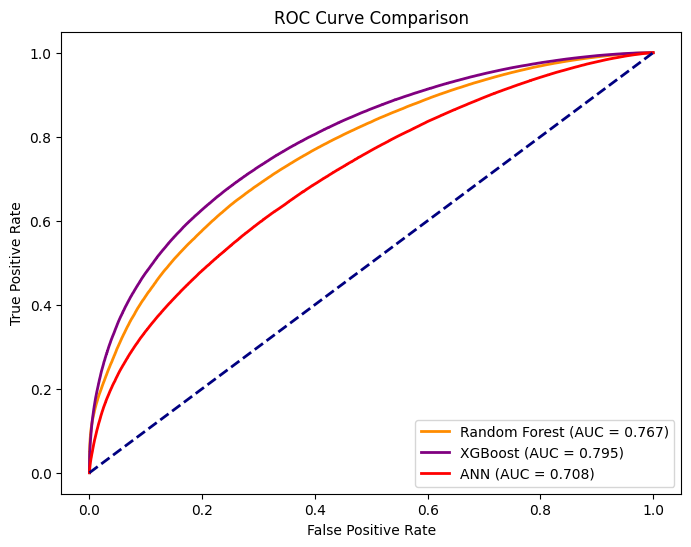

In [26]:
models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "ANN": ann_model
}

plt.figure(figsize=(8, 6))
colors = ['darkorange', 'purple', 'red']

for i, (name, model) in enumerate(models.items()):
    if name == "ANN":
        y_pred_proba = model.predict(X_train_nn).ravel()
        y_pred = (y_pred_proba > 0.5).astype(int)
    else:
        y_pred_proba = model.predict_proba(X_train)[:, 1]
        y_pred = model.predict(X_train)
    
    fpr, tpr, _ = roc_curve(y_train, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')

plt.savefig("roc_curve_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

21875/21875 ━━━━━━━━━━━━━━━━━━━━ 31s 1ms/step


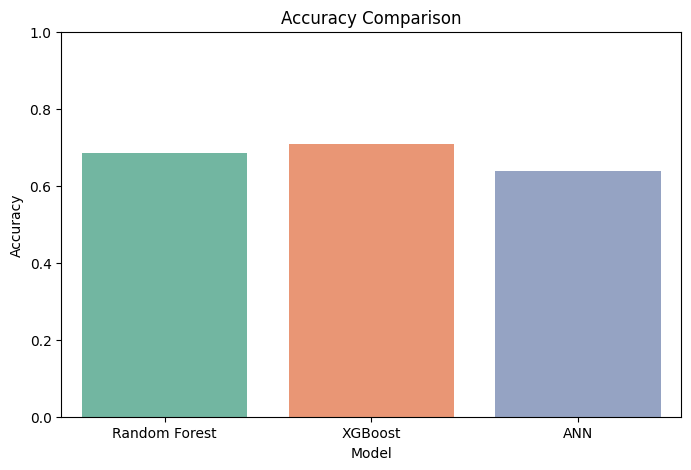

In [27]:
comparison_metrics = []

for name, model in models.items():
    if name == "ANN":
        y_pred_proba = model.predict(X_train_nn).ravel()
        y_pred = (y_pred_proba > 0.5).astype(int)
    else:
        y_pred = model.predict(X_train)
    
    comparison_metrics.append({
        'Model': name,
        'Accuracy': accuracy_score(y_train, y_pred)
    })

metrics_df = pd.DataFrame(comparison_metrics)

plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=metrics_df, palette='Set2')
plt.ylim(0, 1)
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')

plt.savefig("accuracy_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [28]:
best_model_name = results_df.sort_values(by='AUC', ascending=False).iloc[0]['Model']

print(f"\nBest model based on AUC: {best_model_name}")


Best model based on AUC: XGBoost


In [29]:
if best_model_name == "Random Forest":
    joblib.dump(rf_model, "diapredict_model.pkl")
    print("Model saved as diapredict_model.pkl (Random Forest)")

elif best_model_name == "XGBoost":
    joblib.dump(xgb_model, "diapredict_model.pkl")
    print("Model saved as diapredict_model.pkl (XGBoost)")

elif best_model_name == "ANN":
    joblib.dump(preprocessor, "preprocessor.pkl")
    ann_model.save("diapredict_model.h5")
    print("Model saved as diapredict_model (ANN)")

Model saved as diapredict_model.pkl (XGBoost)
